In [28]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm.keras import TqdmCallback

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical 

sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_ABC-SN/")
from plot_data import *
from process_data import *

In [29]:
import tensorflow as tf

# Get the build information dictionary
build_info = tf.sysconfig.get_build_info()

# Print the CUDA version it was built for
print("CUDA Version TensorFlow was built with:", build_info.get('cuda_version', 'Not found'))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

CUDA Version TensorFlow was built with: 12.5.1
Num GPUs Available:  1


In [30]:
file = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/full_preprocessed_dataframe.parquet"
master_df = pd.read_parquet(file)

In [31]:
types, counts = np.unique(master_df.sn_type.values, return_counts = True)
for i in range(len(types)):
    print(types[i], " : ", counts[i])

CaRT  :  52
II  :  1819
IIb  :  542
IIn  :  880
Ia  :  8074
Iap  :  263
Ib  :  262
Ic  :  193
SL  :  1262
TDE  :  96


In [32]:
# Choose the ones with ABC-SN labels only 
index = ~np.isnan(master_df.ABC_type.values)
df = master_df[index]
df = df.reset_index(drop=True)

# creating y array to use for stratification
y = df["ABC_type"].values
index = df.index.values

In [33]:
train_index, test_index = train_test_split(index, test_size = 0.3, random_state = 7, stratify = y)

In [34]:
data = dp.extract_dataframe(df)

wvl = data[1]  # Wavelength array
flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
df_metadata = data[5]  # Sub-dataframe containing only the metadata
fluxes0 = data[6]  # Only the flux values in a numpy array

In [35]:
# one hot encode the y values 
y_ohe = to_categorical(y, num_classes=10)

In [36]:
X = fluxes0.copy()
X = X.reshape(X.shape[0],1,X.shape[1])

X_train = X[train_index]
X_test = X[test_index]

y_train = y_ohe[train_index]
y_test = y_ohe[test_index]

In [39]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y )
class_weight_dict = {int(np.unique(y)[i]):class_weights[i] for i in range(len(class_weights))}

for key in class_weight_dict:
    print(ABC_subtype_id_to_str[key], class_weight_dict[key])


Ia-norm 0.23022458921641484
Ia-91T 7.067807351077313
Ib-norm 7.094783715012722
IIb 3.429581795817958
Ic-norm 9.63126079447323
IIP 1.0218984790177754


In [40]:
np.unique(y)

array([0., 1., 4., 6., 7., 9.])

In [41]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7807, 1, 139), (3346, 1, 139), (7807, 10), (3346, 10))

In [42]:
df_test = df.iloc[test_index].copy()

In [43]:
df_test.ABC_type.unique()

array([0., 6., 1., 9., 4., 7.])

## Loading ABC-SN to make predictions


In [44]:
# Loading model 
abcsn = keras.models.load_model("/lustre/lrspec/users/4301/ABC-SN/abcsn/ABCSN.keras", compile=False)
# abcsn = keras.models.load_model("/lustre/lrspec/users/4301/Milligan_ABC-SN/ABCSN_finetuning100.keras", compile=False)

In [45]:
# need manually compile, using the code from ABC-SN/code/abcsn_training 
loss = keras.losses.CategoricalCrossentropy()
acc = keras.metrics.CategoricalAccuracy(name="ca")
f1 = keras.metrics.F1Score(average="macro", name="f1")
# lr0_transfer=1e-5
# optimizer = keras.optimizers.Nadam(learning_rate=lr0_transfer)

## Add Callbacks

In [46]:
# early stopping 
early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        min_delta=1e-2, # stated during meeting (note higher than willows)
        patience= 25, # stated in meeting + same as willows
        verbose=2,
        mode="min",
        restore_best_weights=True 
        )

model_filepath = "/lustre/lrspec/users/4301/Milligan_ABC-SN/models/model_checkpoint{epoch}.keras"
model_checkpoints = keras.callbacks.ModelCheckpoint(
    model_filepath,
    monitor="val_loss",
    verbose=0,
    mode="min",
    save_best_only=True
    )

epoch_bound = 100
batch_size = 64 # used below
step_bound = len(train_index) * epoch_bound // batch_size

learning_rate_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries=[step_bound],  # Epoch when the change happens
    values=[1e-5, 2e-6]  # Learning rates: [before boundary, after boundary]
    )


In [47]:
optimizer = keras.optimizers.Nadam(learning_rate=learning_rate_schedule)

abcsn.compile(loss=loss, 
              optimizer=optimizer, 
              metrics=[acc, f1],
             )

In [48]:
# Fine-tune from this layer onwards
fine_tune_at = len(abcsn.layers)-8

# Freeze all the layers before the `fine_tune_at` layer
for layer in abcsn.layers[:fine_tune_at]:
    layer.trainable = False

In [49]:
# abcsn.summary()

In [50]:
len(abcsn.trainable_variables)

8

## Retraining

In [51]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7807, 1, 139), (3346, 1, 139), (7807, 10), (3346, 10))

In [52]:
history = abcsn.fit(X_train, y_train, 
                    validation_data= (X_test, y_test), 
                    epochs = 500,    # choosen arbitrarily 
                    batch_size = 64, # same as willow used
                    verbose= 0,
                    callbacks=[model_checkpoints, early_stop, TqdmCallback(verbose=0)]
                   )


0epoch [00:00, ?epoch/s]
 74%|███████▍  | 369/500 [24:14<08:36,  3.94s/epoch, ca=0.88, f1=0.253, loss=0.757, val_ca=0.874, val_f1=0.249, val_loss=0.796]
2026-07-09 11:57:27.979281: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}

 85%|████████▌ | 425/500 [26:33<04:27,  3.57s/epoch, ca=0.887, f1=0.275, loss=0.717, val_ca=0.873, val_f1=0.246, val_loss=0.767]

Epoch 425: early stopping
Restoring model weights from the end of the best epoch: 400.


 85%|████████▌ | 425/500 [26:33<04:41,  3.75s/epoch, ca=0.887, f1=0.275, loss=0.717, val_ca=0.873, val_f1=0.246, val_loss=0.767]


In [54]:
np.argmin(history.history['val_loss'])

np.int64(422)

In [55]:
history.history.keys()

dict_keys(['ca', 'f1', 'loss', 'val_ca', 'val_f1', 'val_loss'])

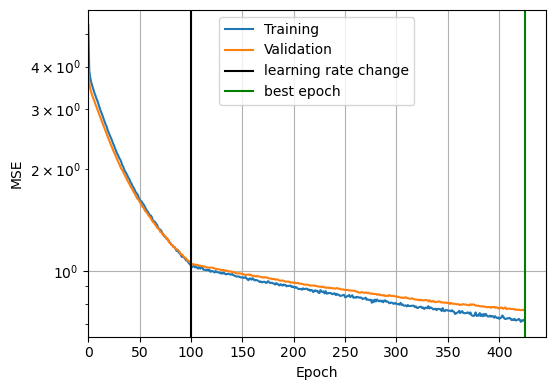

In [58]:
log = history.history
abcsn_training.plot_loss(log, scale=4, cb_es=None, patience_es=None)
plt.axvline(epoch_bound, label= "learning rate change", color = 'k')
plt.axvline(425, label= "best epoch", color = 'g')
plt.legend()
# plt.ylim(4,5)

In [130]:
pwd

'/lustre/lrspec/users/4301/Milligan_ABC-SN/notebooks'

In [53]:
abcsn.save("/lustre/lrspec/users/4301/Milligan_ABC-SN/ABCSN_finetuning500_es.keras")

## Results

In [60]:

# predict type
P = abcsn.predict(X_test, verbose=0)
P_argmax = np.argmax(P, axis=1)

df_test["Pred_ABC_ID"] = P_argmax

# get type as milligan ID
ABC_to_Mill = get_ABC_to_Mill_dict()
P_Mill = np.array([ABC_to_Mill[i] for i in P_argmax])
df_test["Pred_Mill_ID"] = P_Mill


2026-07-09 12:59:16.916945: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


### Checking various types

In [61]:
# Predicted ABC id counts
np.unique(P_argmax, return_counts=True)

(array([0, 1, 4, 6, 9]), array([2554,    4,    8,  104,  676]))

In [62]:
# true ABC ids
Y_ABC_IDs = df_test.ABC_type.values
np.unique(Y_ABC_IDs, return_counts=True)

(array([0., 1., 4., 6., 7., 9.]), array([2422,   79,   78,  163,   58,  546]))

In [63]:
np.unique(P_Mill, return_counts=True)

(array([0, 1, 2]), array([2558,  112,  676]))

# Looking at the results of prediction with ABCSN labels

In [64]:

cr = (classification_report(
    Y_ABC_IDs,
    P_argmax,
    labels=list(ABC_subtype_id_to_str.keys()),
    target_names=list(ABC_subtype_id_to_str.values())
    ))

print(cr)
#may be skewed 

              precision    recall  f1-score   support

     Ia-norm       0.91      0.96      0.94      2422
      Ia-91T       0.75      0.04      0.07        79
     Ia-91bg       0.00      0.00      0.00         0
         Iax       0.00      0.00      0.00         0
     Ib-norm       0.12      0.01      0.02        78
         Ibn       0.00      0.00      0.00         0
         IIb       0.72      0.46      0.56       163
     Ic-norm       0.00      0.00      0.00        58
    Ic-broad       0.00      0.00      0.00         0
         IIP       0.75      0.93      0.83       546

    accuracy                           0.87      3346
   macro avg       0.33      0.24      0.24      3346
weighted avg       0.84      0.87      0.85      3346



/home/4301/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/4301/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/4301/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

In [65]:
df_test

,ABC_type,Mill_type,SN_mag,Spectral Phase,host,host_mag,redshift,sn_type,2512.529050300541,2537.7127325827696,...,9279.405394966827,9372.415104528947,9466.357072754703,9561.240643896645,9657.075255867012,9753.870441176497,9851.635827882466,9950.38114054659,Pred_ABC_ID,Pred_Mill_ID
2642,0.0,0.0,21.328,0.0,sb,23.906,0.203130,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
7125,0.0,0.0,17.907,0.0,sc,16.310,0.039275,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
6627,0.0,0.0,19.808,0.0,sb,21.986,0.201020,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
8561,0.0,0.0,21.387,0.0,sb,20.690,0.200820,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
8913,0.0,0.0,22.909,0.0,sc,22.655,0.342230,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5175,9.0,2.0,22.396,0.0,sa,22.390,0.245990,II,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,2
2245,0.0,0.0,22.500,0.0,sc,21.748,0.370850,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2713,0.0,0.0,22.285,0.0,sb,24.863,0.394130,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
279,0.0,0.0,22.746,0.0,sb,24.884,0.479130,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


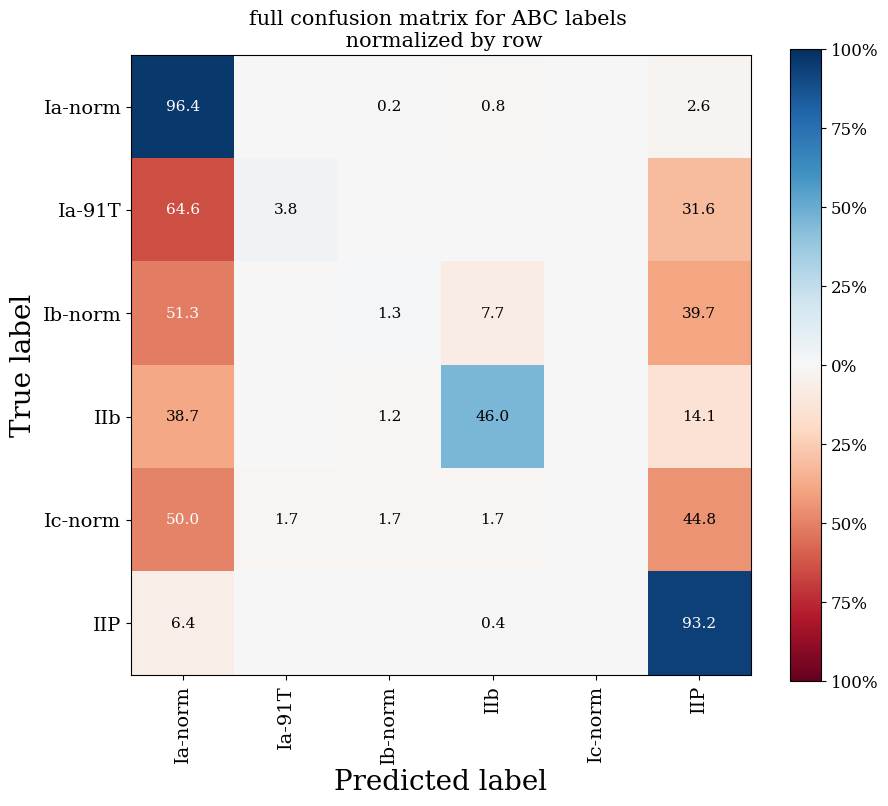

In [66]:
ABC_ID_dict = get_ABC_ID_dict()
labels = [ABC_ID_dict[id] for id in np.unique(Y_ABC_IDs)]


cm = confusion_matrix(df_test.ABC_type.values, 
                      df_test.Pred_ABC_ID.values,
                     labels = np.unique(Y_ABC_IDs))
plot = plot_cm(cm, labels, 
               title = "full confusion matrix for ABC labels \n normalized by row",
              normalize = True)

## look at various normalizations

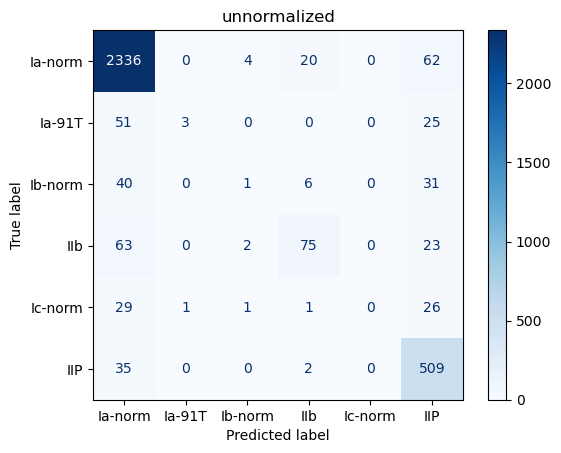

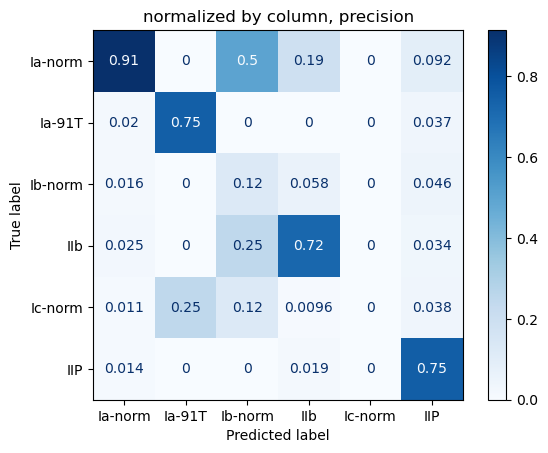

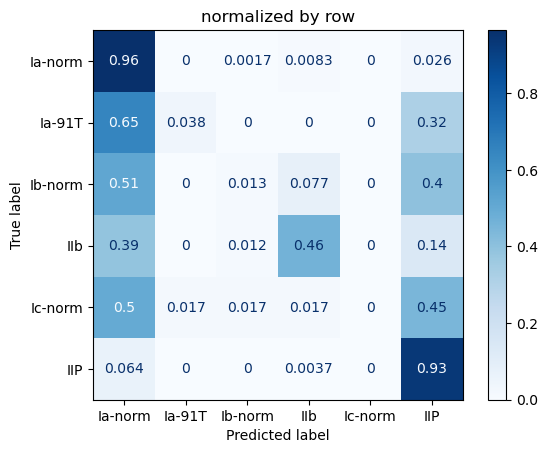

In [67]:
normalizations = [None, "pred", "true"]
titles = ["unnormalized", "normalized by column, precision", "normalized by row"]

for i in range(3):
    cm = confusion_matrix(df_test.ABC_type.values, 
                          df_test.Pred_ABC_ID.values, 
                          labels=np.unique(Y_ABC_IDs)[:],
                          normalize=normalizations[i])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)
    disp.plot(cmap='Blues')
    plt.title(titles[i])
    plt.show()

## Looking at close and bright SN objects

In [68]:

brighter_SN_index = df_test.host_mag > df_test.SN_mag + 1
small_z_index = df_test.redshift < 0.05
print(sum(small_z_index & brighter_SN_index))
bright_close_index = small_z_index & brighter_SN_index

bright_close_SN_df = df_test[bright_close_index].copy()

41


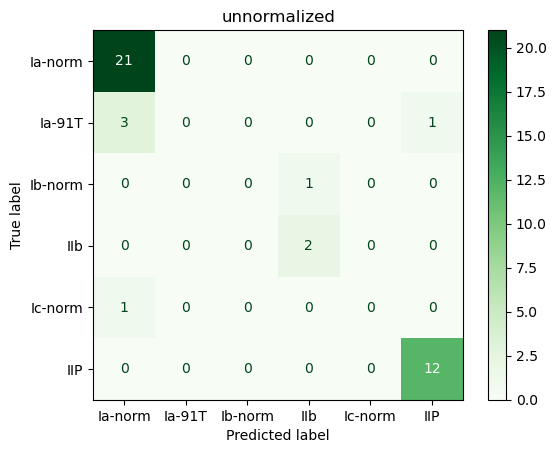

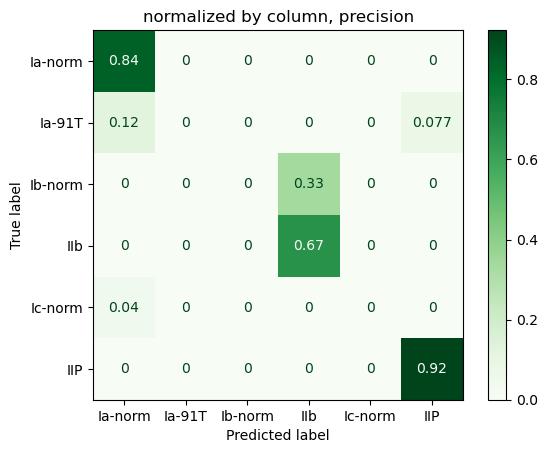

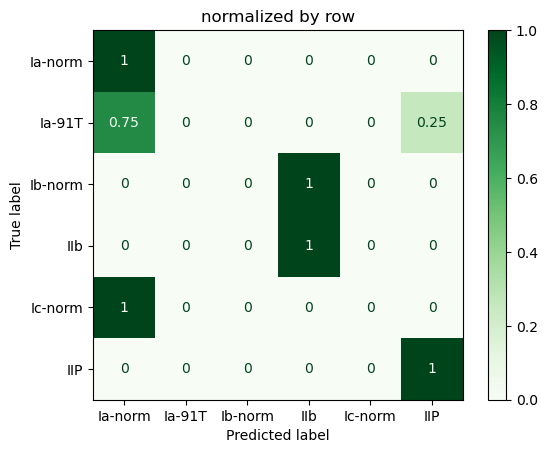

In [69]:
normalizations = [None, "pred", "true"]
titles = ["unnormalized", "normalized by column, precision", "normalized by row"]

for i in range(3):
    cm = confusion_matrix(bright_close_SN_df.ABC_type.values, 
                          bright_close_SN_df.Pred_ABC_ID.values, 
                          labels=np.unique(Y_ABC_IDs),
                          normalize=normalizations[i])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)
    disp.plot(cmap='Greens')
    plt.title(titles[i])
    plt.show()

## Using Milligan Labels

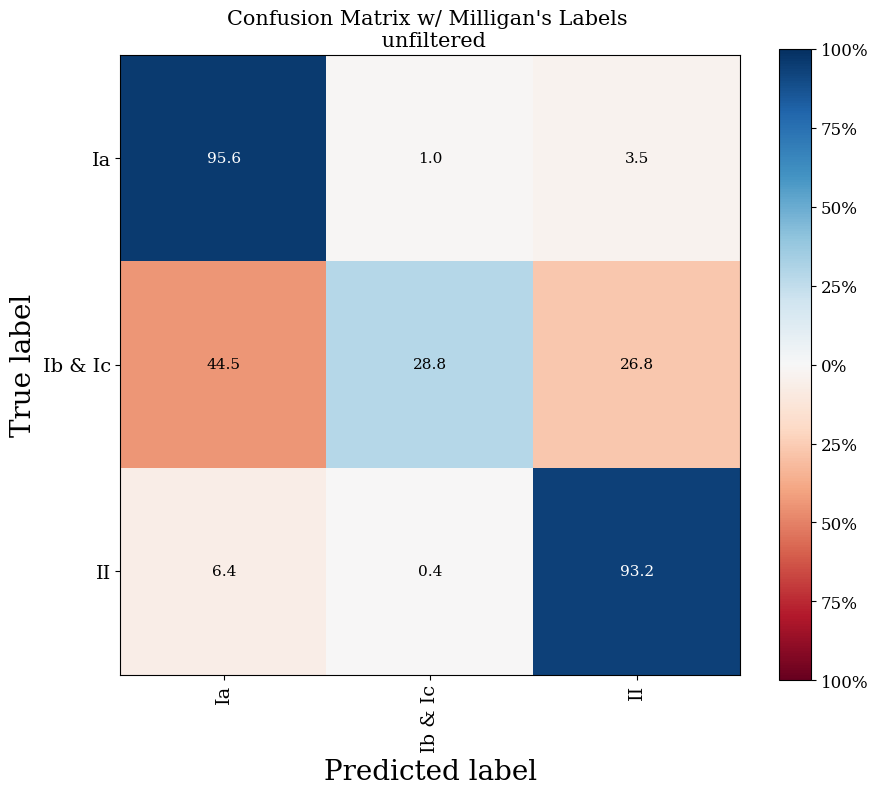

In [70]:

cm_mill = confusion_matrix(df_test.Mill_type, df_test.Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3], 
        title = "Confusion Matrix w/ Milligan's Labels \n unfiltered")

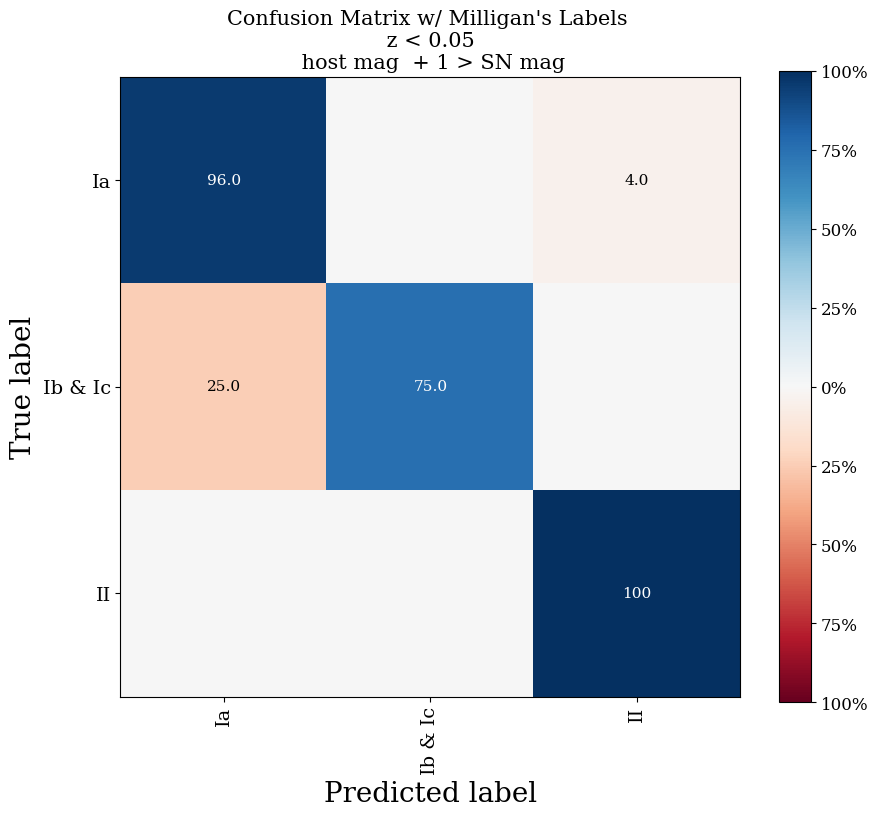

In [71]:
cm_mill = confusion_matrix(bright_close_SN_df.Mill_type, bright_close_SN_df.Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3], 
        title = "Confusion Matrix w/ Milligan's Labels \n z < 0.05 \n host mag  + 1 > SN mag")

# Looking at classification spectra ... not particulary useful

/tmp/ipykernel_36216/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_36216/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_36216/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_36216/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_36216/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")


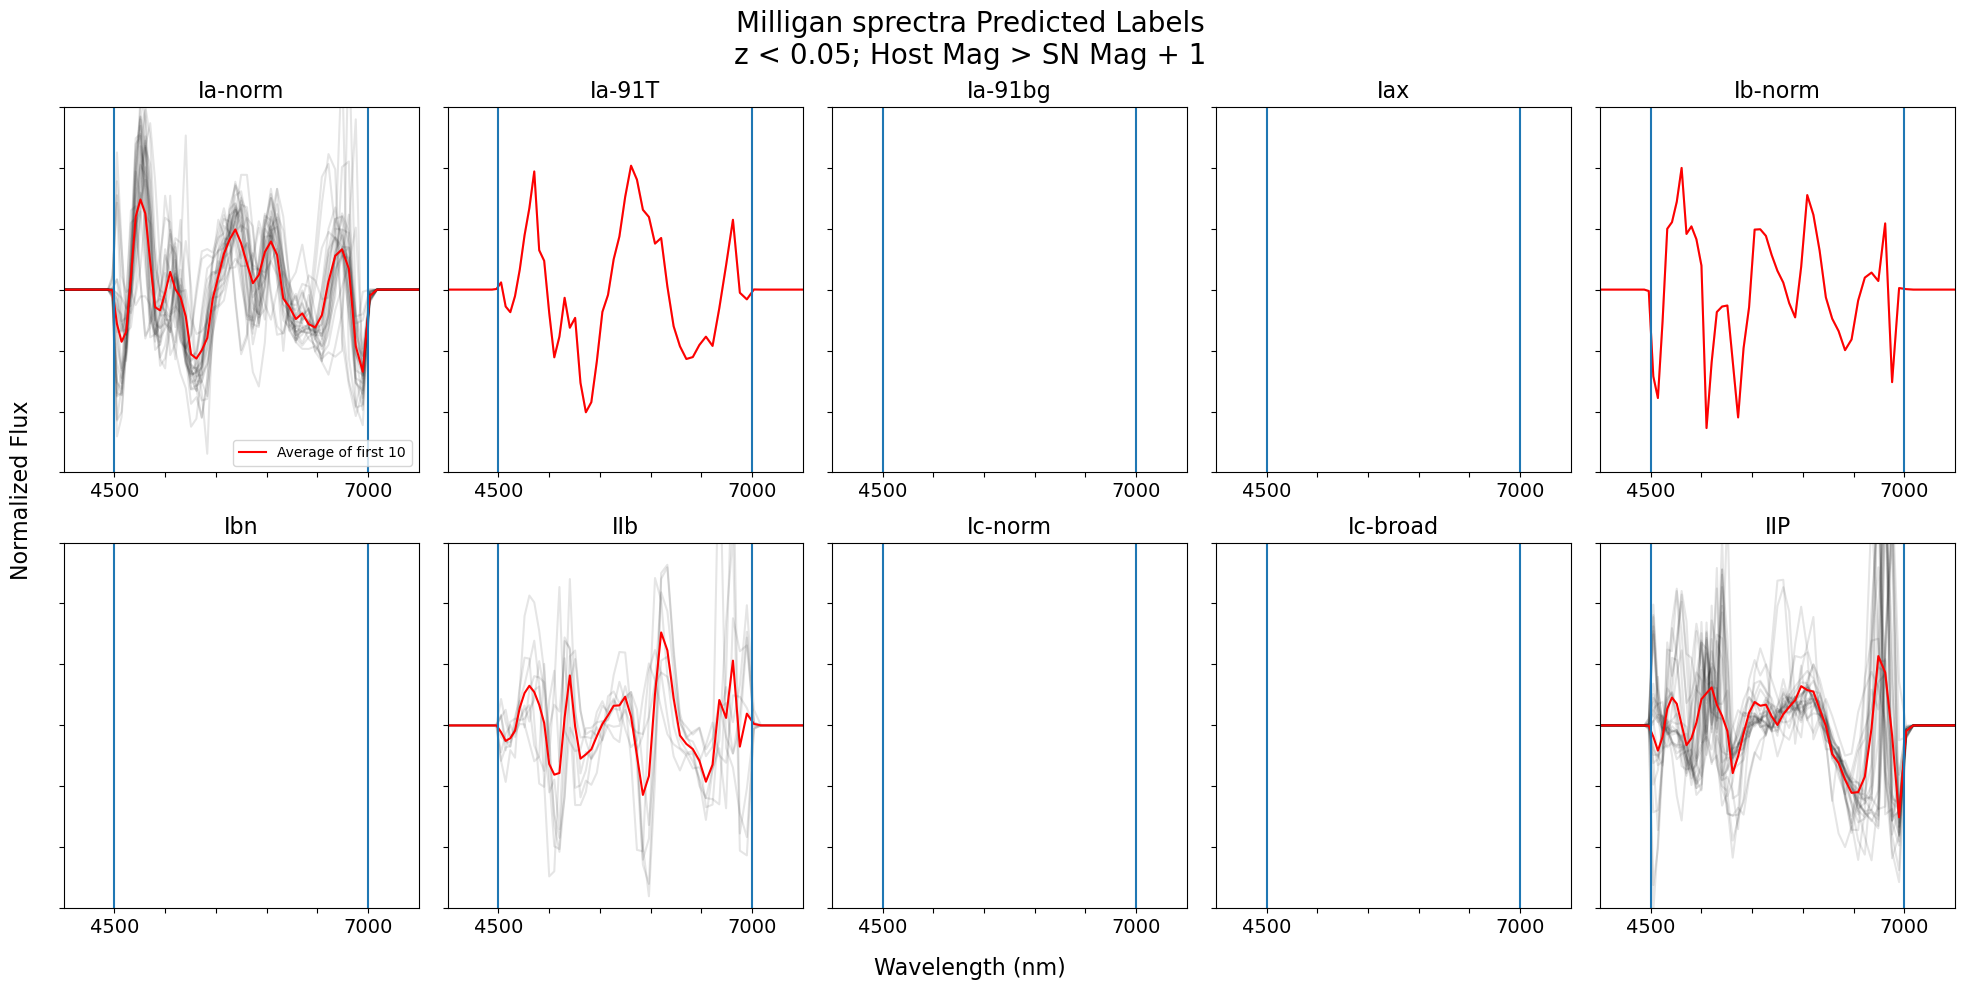

In [72]:
types = list(ABC_subtype_id_to_str.keys())
types_titles = list(ABC_subtype_id_to_str.values())
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration
brighter_SN_index = df_test.host_mag > df_test.SN_mag +1
small_z_index = df_test.redshift < 0.05
close_bright_df = df_test[small_z_index] #df[brighter_SN_index & small_z_index]
num_wvl = 139
flux_start, flux_stop = 59, 103


for j, sn_type in enumerate(types):
    ax = axes[j]
    temp_df = close_bright_df[close_bright_df.Pred_ABC_ID == sn_type]
    
    dat_size = len(temp_df)
    X_temp = np.zeros((num_wvl, ))

    for n, i in enumerate(temp_df.index.values):
        if n < 10:
            X_temp += fluxes0[i]
        if n < 25:
            ax.plot(wvl, fluxes0[i], alpha = 0.1, color = "k")

    if dat_size < 10:
        ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
    else:
        ax.plot(wvl, X_temp/10 , alpha = 1, color = "r", label="Average of first 10")
    ax.set_title(f"{types_titles[j]}", fontsize = 16)
    ax.set_ylim(-3, 3)
    ax.set_xlim(4000,7500)
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels(['', '', '', '', '', ''])
    ax.set_yticks([-3,-2,-1, 0, 1,2,3])
    ax.set_yticklabels(["", "", " ", " ", "", "", "" ])
    if j == 0:
        ax.legend()
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels([4500, '', '', '', '', 7000], fontsize = 14)

    ax.axvline(4500)
    ax.axvline(7000)

fig.suptitle("Milligan sprectra Predicted Labels\nz < 0.05; Host Mag > SN Mag + 1", fontsize =20)

fig.supxlabel("Wavelength (nm)", fontsize = 16)
fig.supylabel("Normalized Flux\n", fontsize = 16)


plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
